##*데이터를 가져오기 위해 깃허브와 연동

In [1]:
!git clone 'https://'github.com/KangKyungHwa/DSMH/''

Cloning into 'DSMH'...
remote: Enumerating objects: 388, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 388 (delta 71), reused 13 (delta 13), pack-reused 258 (from 1)
Receiving objects: 100% (388/388), 24.19 MiB | 25.15 MiB/s, done.
Resolving deltas: 100% (182/182), done.


##*한글깨짐 방지를 위해 폰트 설정

In [ ]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

## *실습 - 결측값,  이상치 처리


###1."Age" 결측치 ---> 채우기 전/후 시각화 비교

<Axes: >

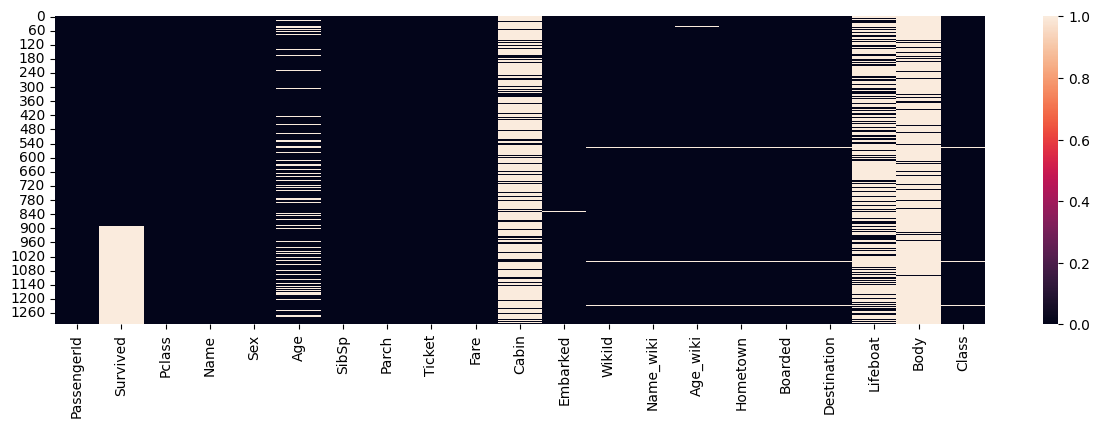

In [7]:
import pandas as pd      # pd  라는 별칭으로 pandas의 기능에 접근
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # 결측값을 시각적으로 탐색하고 분석하는 데 사용되는 라이브러리

df = pd.read_csv("DSMH/example_data/sample_5/titanic_full.csv")  #데이터 불러오기
plt.figure(figsize=(15, 4))
sns.heatmap(df.isnull()) # Age 결측값 처리전 시각 자료


/tmp/ipykernel_14073/2518373449.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["Age"].fillna(test_df["Age"].median(),inplace=True) # Age 결측값을 중앙값으로 대체


<Axes: >

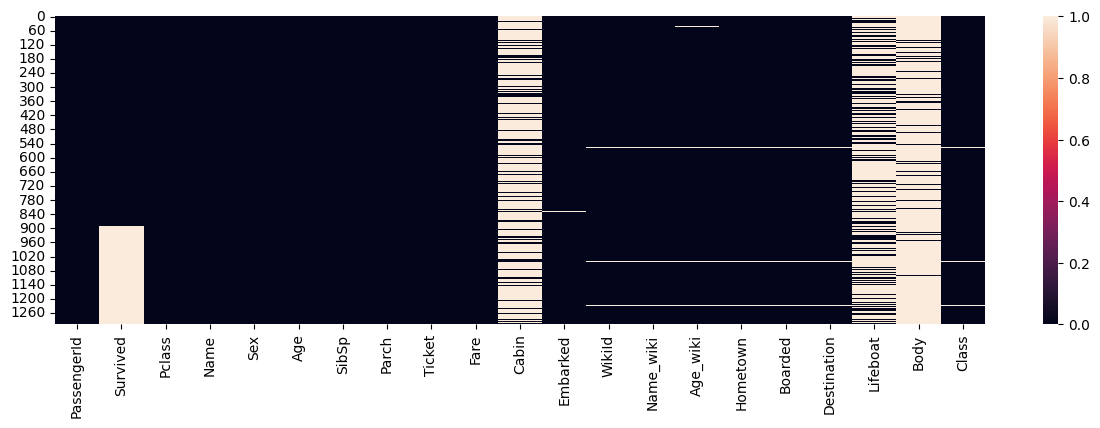

In [8]:
test_df = df.copy()  #자료보관을 위해 원본을 두고 새로운 데이터 복사하여 사용함
test_df["Age"].fillna(test_df["Age"].median(),inplace=True) # Age 결측값을 중앙값으로 대체
plt.figure(figsize=(15, 4))
sns.heatmap(test_df.isnull()) # Age 결측값 처리  후 시각 자료

###2."Fare" 이상치 제거 전/후평균값 비교

In [9]:
test_df.describe()  # 이상치 제거하기전 Fare의 최대값은 512 이상

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,WikiId,Age_wiki,Class
count,1309.000000,891.000000,1309.000000,1309.000000,1309.000000,1309.000000,1308.000000,1304.000000,1302.000000,1304.000000
mean,655.000000,0.383838,2.294882,29.503186,0.498854,0.385027,33.295479,658.534509,29.415829,2.291411
std,378.020061,0.486592,0.837836,12.905241,1.041658,0.865560,51.758668,380.377373,13.758954,0.840852
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,1.000000,0.170000,1.000000
25%,328.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800,326.750000,21.000000,1.750000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,661.500000,28.000000,3.000000
75%,982.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.275000,987.250000,37.750000,3.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1314.000000,74.000000,3.000000


##*IQR(사분위범위)란?

**1.사분위 범위**
사분위 범위(interquartile range, IQR)는 통계에서 자료의 산포(흩어짐)를 나타내는 지표로, 데이터의 중간 50%가 분포하는 범위를 의미-->데이터가 중앙부에서 얼마나 퍼져 있는지를 수치로 보여 줌

**2.계산 방법**
사분위 범위는 전체 자료를 크기순으로 정렬한 뒤
하위 25% 지점(Q1)과 상위 25% 지점(Q3) 차이를 계산한다.
예) Q1=20, Q3=40이면 사분위 범위는 20

공식: IQR = Q3 − Q1
제3사분위수(Q3)와 제1사분위수(Q1)의 차이

**3.통계적 의미**
1)사분위 범위는 표준편차와 달리 평균을 기준으로 하지 않기 때문에,
2)극단값이 포함된 분포에서도 안정적인 변동성 척도를 제공
3)탐색적 자료 분석(EDA)에 유용

**4.활용**
박스그림(Box plot)에서 상자 길이로 시각화되며, 이상치 판별에 자주 이용됨 일반적으로 데이터 값이 Q1−1.5×IQR보다 작거나 Q3+1.5×IQR보다 크면 이상치로 간주

In [10]:
#Fare의 사분위범위
IQR = test_df["Fare"].describe()["75%"]-test_df["Fare"].describe()["25%"]
print(IQR)

23.379199999999997


In [14]:
weight=1.5  #일반적으로 1.5배 곱해준다
lower_bound=test_df["Fare"].describe()["25%"]-(weight*IQR)  #예: 25%(7.8958)-(23.3791*1.5)=-27.1729
print(lower_bound)

upper_bound=test_df["Fare"].describe()["75%"]+(weight*IQR)  #예: 75%(31.275)+(23.3791*1.5)=
print(upper_bound)  # upper_bound 값 65.6344 이상은 이상치로 간주



-27.172999999999995
66.34379999999999


<Axes: >

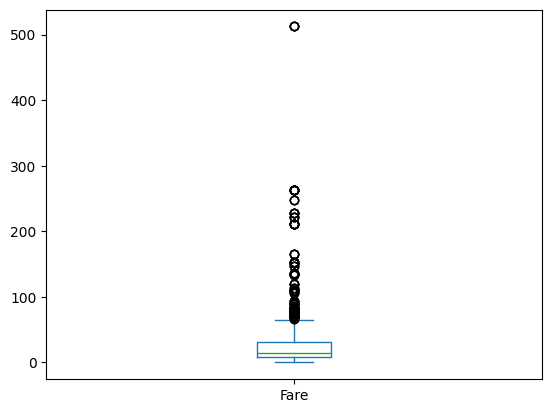

In [11]:
test_df["Fare"].plot(kind="box")  #이상치 수정되기 전 box그림

In [15]:
(test_df["Fare"]<= upper_bound).mean()*100     #upper_bound 이상은 제외한다

np.float64(86.86019862490451)

In [16]:
test_df[test_df["Fare"] <= upper_bound]   # 86.9809% 의 데이터만 나타남  (775개)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0
5,6,0.0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,...,Q,785.0,"Doherty, Mr. William John (aka ""James Moran"")",22.0,"Cork, Ireland",Queenstown,New York City,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,1304,NaN,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,...,S,869.0,"Henriksson, Miss Jenny Lovisa",28.0,"Stockholm, Sweden",Southampton,"Iron Mountain, Michigan, US",NaN,3MB,3.0
1304,1305,NaN,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,...,S,1227.0,"Spector, Mr. Woolf",23.0,"London, England",Southampton,New York City,NaN,NaN,3.0
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,...,S,1169.0,"Sæther, Mr. Simon Sivertsen",43.0,"Skaun, Sør-Trøndelag, Norway",Southampton,US,NaN,32MB,3.0
1307,1308,NaN,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,...,S,1289.0,"Ware, Mr. Frederick William",34.0,"Greenwich, London, England",Southampton,New York City,NaN,NaN,3.0


In [18]:
new_test_df=test_df.copy()  # 이상치를 제거한 86.9809%의 데이터만 new_test_df에 따로 떼어 보관

In [19]:
new_test_df=test_df[test_df["Fare"] <= upper_bound]  # 86.9809% 의 데이터(775개)를 new_test_df 넣어준다

###3."Fare" 값  65.6344 보다 큰 이상치 제거 후 new_test_df 데이타셋에 들어있는 자료의  box그림

<Axes: >

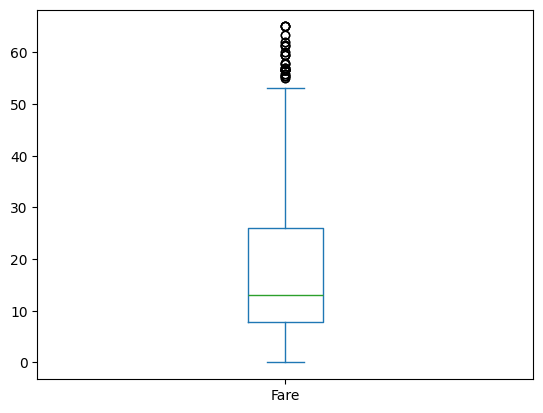

In [20]:
new_test_df["Fare"].plot(kind="box") # box 그림으로 시각화 하기

###4.그림이 아닌 수치적으로도 확인해 보기

In [21]:
new_test_df.describe()  # # 이상치 제거  후 Fare의 최대값은 65

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,WikiId,Age_wiki,Class
count,1137.000000,775.000000,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000,1134.000000,1132.000000,1134.000000
mean,653.149516,0.339355,2.463500,28.552551,0.418646,0.328936,17.962074,719.726631,28.493366,2.457672
std,377.983079,0.473796,0.740393,12.301978,0.852051,0.770825,13.829925,354.914585,13.289401,0.746553
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,3.000000,0.170000,1.000000
25%,329.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.879200,442.250000,20.000000,2.000000
50%,654.000000,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000,734.500000,27.000000,3.000000
75%,979.000000,1.000000,3.000000,33.000000,1.000000,0.000000,26.000000,1017.750000,36.000000,3.000000
max,1309.000000,1.000000,3.000000,80.000000,5.000000,6.000000,65.000000,1314.000000,74.000000,3.000000
